In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nikit\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import seaborn as sns
import numpy as np 

from forecaster import plot_dynamic, multi_model_forecast

In [4]:
df = pd.read_excel('example.xlsx')

In [5]:
df

,Дата,sold,unsold
0,2020-01-01,43874642.76,37239888.21
1,2020-02-01,42722019.09,35597505.12
2,2020-03-01,43398524.47,34680760.38
3,2020-04-01,43614432.76,33980906.36
4,2020-05-01,42737331.66,32930309.82
...,...,...,...
68,2025-09-01,37948237.91,54904519.55
69,2025-10-01,38015630.52,54480654.78
70,2025-11-01,38251136.54,54840118.23
71,2025-12-01,39143026.43,54691253.48


                   ADF      KPSS        PP
Исходный ряд  0.481076  0.011852  0.563503


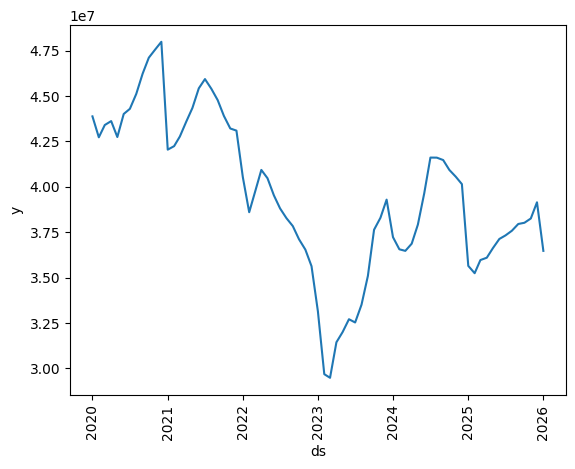

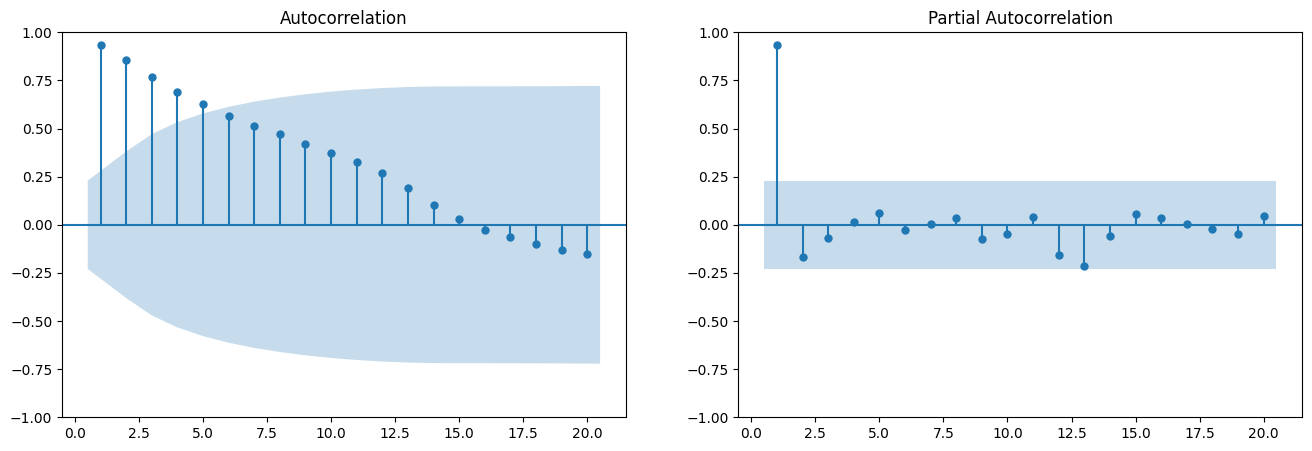

22:53:25 - cmdstanpy - INFO - Chain [1] start processing
22:53:27 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-14 22:53:27,417] A new study created in memory with name: no-name-9b2c0a61-ba4c-4cc3-82e5-b36b1c57d110
c:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible star

Best params: (4, 0, 1) trend: n


TypeError: '>' not supported between instances of 'str' and 'int'

In [8]:
y = df[['Дата', 'sold']]
pred_stat, stat_df = multi_model_forecast(y, 24, test_size = 0.2, seasonal_preiod = 12, freq = 'MS', value_name = 'sold')

D:\University\Диплом\simple_forecaster\forecaster.py:152: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result.loc['Исходный ряд', 'KPSS'] = kpss(series)[1]


                  ADF  KPSS        PP
Исходный ряд  0.97834  0.01  0.989903


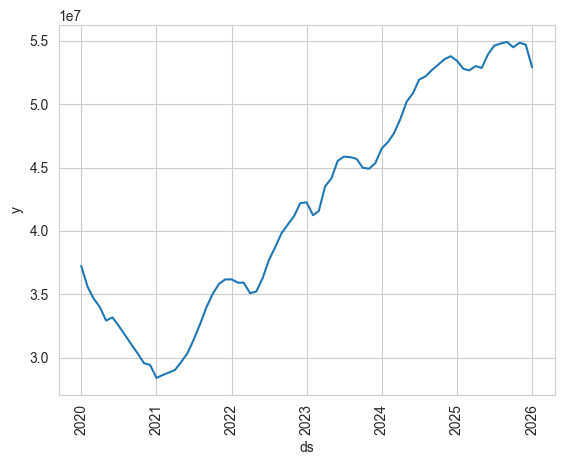

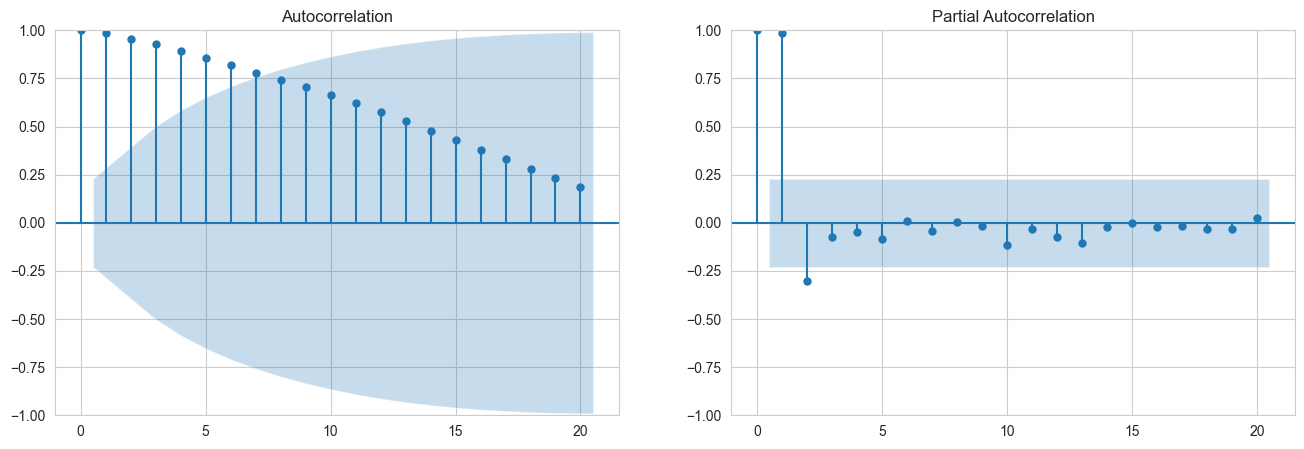

11:57:30 - cmdstanpy - INFO - Chain [1] start processing
11:57:31 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\University\Диплом\simple_forecaster\forecaster.py:346: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  exp_model = ExponentialSmoothing(endog = y_train['y'], seasonal_periods = seasonal_preiod, **study.best_params).fit()


,Test_MAE,Test_MAPE,Test_RMSE,Test_WAPE,Train_MAE,Train_MAPE,Train_RMSE,Train_WAPE
Model,,,,,,,,
prop,3.324137e+06,6.157415,3.870982e+06,6.175208,6.854716e+05,1.766865,8.350237e+05,1.749000
ar,6.114133e+06,11.330381,6.794398e+06,11.358149,1.639919e+06,4.488665,6.573171e+06,4.184301
exp,1.271245e+06,2.361729,1.397956e+06,2.361576,4.070637e+05,1.070955,5.191267e+05,1.038635
Ensemble,2.585644e+06,4.793923,2.903337e+06,4.803318,4.552448e+05,1.226782,9.773286e+05,1.161570


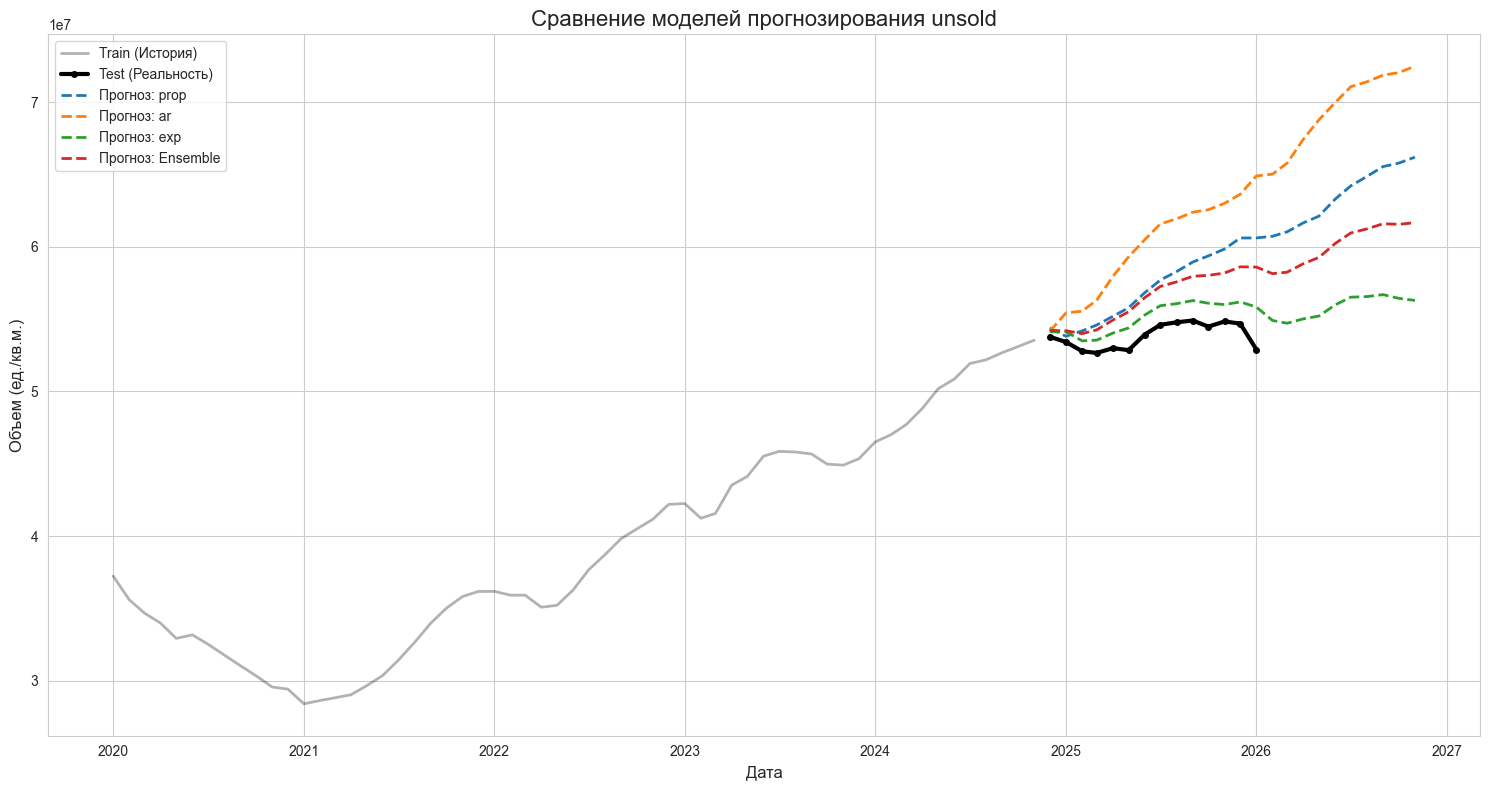

In [9]:
y = df[['Дата', 'unsold']]
pred_stat, stat_df = multi_model_forecast(y, 24, test_size = 0.2, seasonal_preiod = 12, freq = 'MS', value_name = 'unsold')

D:\University\Диплом\simple_forecaster\forecaster.py:152: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result.loc['Исходный ряд', 'KPSS'] = kpss(series)[1]


                   ADF  KPSS        PP
Исходный ряд  0.821263  0.01  0.848129


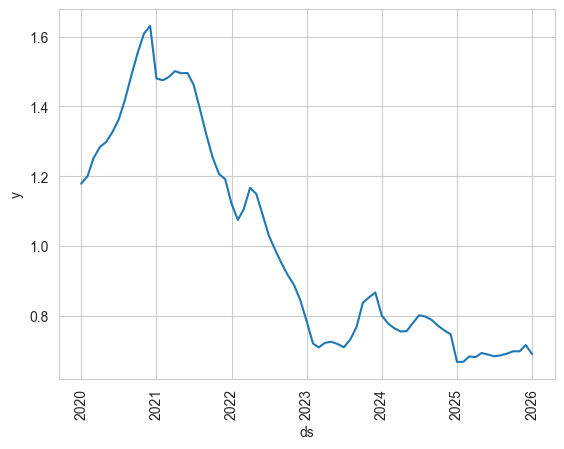

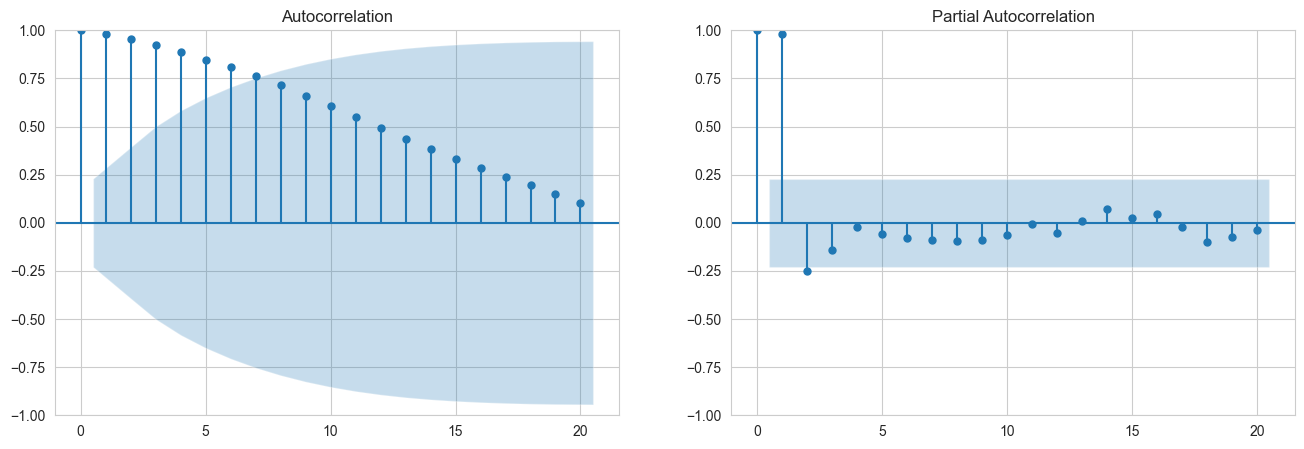

11:58:01 - cmdstanpy - INFO - Chain [1] start processing
11:58:02 - cmdstanpy - INFO - Chain [1] done processing
D:\University\Диплом\simple_forecaster\forecaster.py:346: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  exp_model = ExponentialSmoothing(endog = y_train['y'], seasonal_periods = seasonal_preiod, **study.best_params).fit()


,Test_MAE,Test_MAPE,Test_RMSE,Test_WAPE,Train_MAE,Train_MAPE,Train_RMSE,Train_WAPE
Model,,,,,,,,
prop,0.181561,26.227871,0.190220,26.238720,0.118259,11.617957,0.136947,11.011938
ar,0.022743,3.273085,0.027277,3.286791,0.037686,3.443830,0.166483,3.509185
exp,0.018218,2.637533,0.021733,2.632840,0.018439,1.804656,0.023338,1.716949
Ensemble,0.023291,3.377872,0.026638,3.365960,0.023415,2.244852,0.050878,2.180381


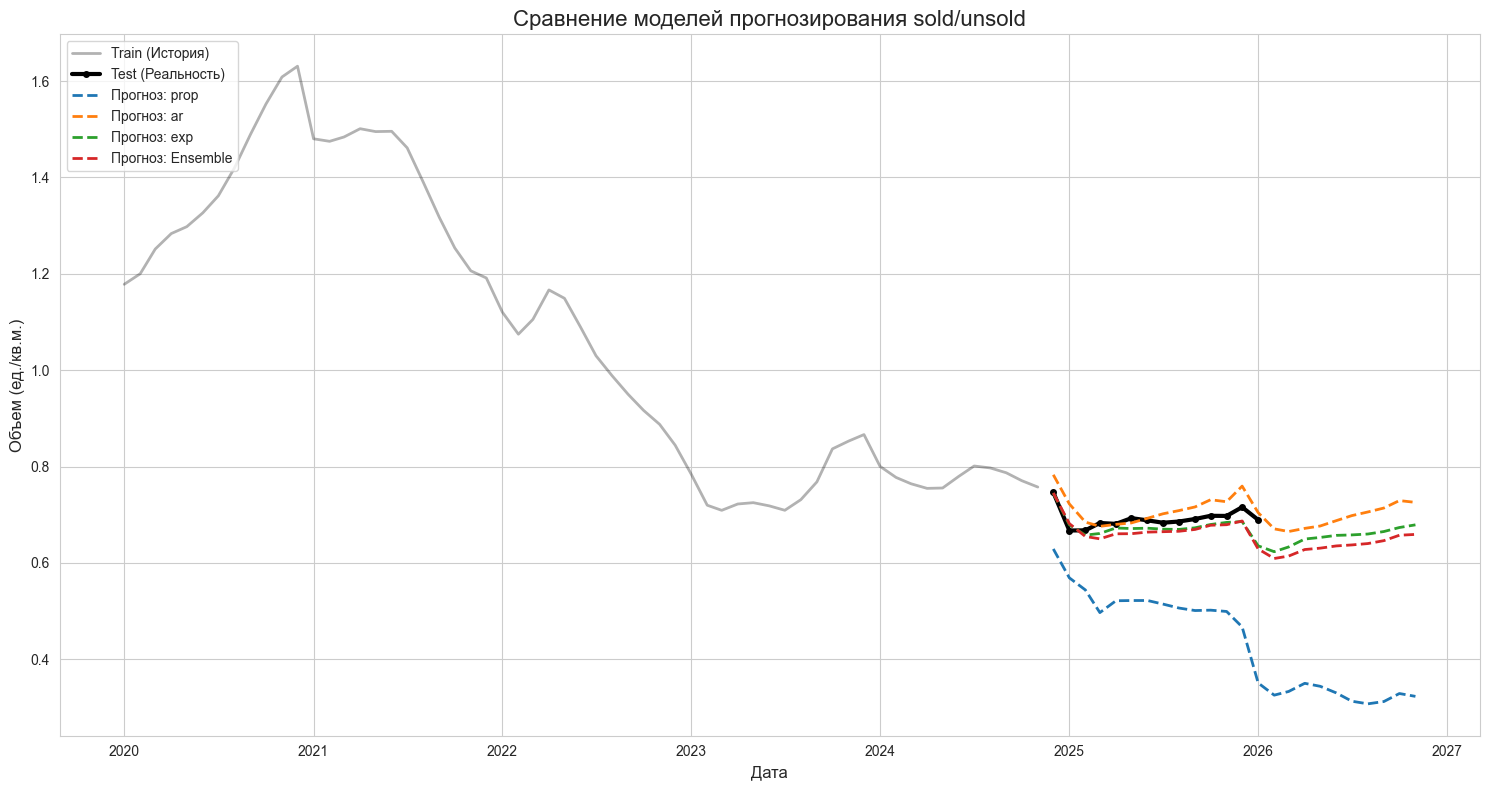

In [10]:
df['sold/unsold'] = df['sold']/df['unsold']
y = df[['Дата', 'sold/unsold']]
pred_stat, stat_df = multi_model_forecast(y, 24, test_size = 0.2, seasonal_preiod = 12, freq = 'MS', value_name = 'sold/unsold')

In [12]:
pred_stat['Ensemble']['weights']

{'prop': 0.09477147742380473,
 'ar': 0.29739601333432736,
 'exp': 0.6078325092418678}